# Genie Space Curation — "customer genie"

### Source : KNOWLEDGE_RETRIEVAL_3/genie_space_curation.ipynb

### Maps to exam bullet:
- Select which Unity Catalog objects (managed tables, views, parameterized queries, SQL functions)
  to curate into a Genie space for a given business domain.


### This notebook uses a real Genie space
Instead of simulating a Genie space, this notebook documents and *queries* the actual
**"customer genie"** space built in last chapter, exactly as curated in the walkthrough:
five managed tables, AI-generated column descriptions, one text instruction, three join
relationships, one example SQL query, and three benchmark questions.

## What was curated, and why ?

- Managed tables : The 5 tables needed to answer customer + order questions. Well under the 30-table limit; stays focused on one business domain.
- Column descriptions : Genie reads UC column comments to decide which column to query.
- Join relationships : Declared explicitly instead of relying on Genie to infer them from naming alone.
- Text instruction : "never include `registration_date` for privacy reasons" , A prompt-level guard. 
- Example SQL query : order-amount distribution, against the table `orders feature`. It Teaches Genie a frequent aggregate pattern. 
- Benchmark questions : 3 NL questions with the SQL Genie produced, used for regression testing 

No SQL functions or parameterized queries were curated in this spaces. If a future business question needs logic that can't be expressed as a
join or aggregate (e.g. a custom discount formula), that is exactly when you'd add a UC SQL function instead of a text instruction.


## Setup
A `.env` file with `DATABRICKS_HOST`, `DATABRICKS_TOKEN`, and your Genie space ID

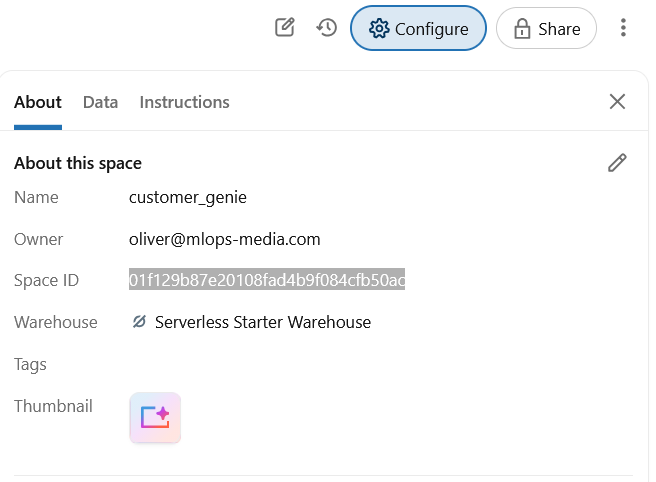

![image.png](attachment:image.png)

In [ ]:
import os
from dotenv import load_dotenv
import sys
sys.path.append(os.path.abspath(".."))

load_dotenv()

assert os.getenv("DATABRICKS_HOST"), "DATABRICKS_HOST not set -- check your .env file"
assert os.getenv("DATABRICKS_TOKEN"), "DATABRICKS_TOKEN not set -- check your .env file"

# TODO: set this to the Genie Space ID of your own "customer genie" space (Configure > Settings)
GENIE_SPACE_ID = os.getenv("GENIE_SPACE_ID", "<TODO-fill-in-your-genie-space-id>")

## Imports and config

In [ ]:
import time
import json
import requests
import mlflow

HOST = os.getenv("DATABRICKS_HOST").rstrip("/")
TOKEN = os.getenv("DATABRICKS_TOKEN")
HEADERS = {"Authorization": "Bearer " + TOKEN, "Content-Type": "application/json"}

# TODO: change "oliver@mlops-media.com" to your own workspace user email
mlflow.set_experiment("/Users/oliver@mlops-media.com/genie_space_curation")
print("Workspace host:", HOST)
print("Genie space id:", GENIE_SPACE_ID)

---
## 1 - Helpers to drive the Genie Conversation API

Two REST calls: start a conversation with a question, then poll the message until Genie has
finished generating + executing the SQL.


In [ ]:
def genie_ask(question, space_id=None, timeout_s=60, poll_every_s=2):
    """Send one natural-language question to a Genie space and return the final message payload."""
    space_id = space_id or GENIE_SPACE_ID
    start = requests.post(
        f"{HOST}/api/2.0/genie/spaces/{space_id}/start-conversation",
        headers=HEADERS,
        json={"content": question},
    )
    start.raise_for_status()
    payload = start.json()
    conversation_id = payload["conversation_id"]
    message_id = payload["message_id"]

    deadline = time.time() + timeout_s
    while time.time() < deadline:
        msg = requests.get(
            f"{HOST}/api/2.0/genie/spaces/{space_id}/conversations/{conversation_id}/messages/{message_id}",
            headers=HEADERS,
        )
        msg.raise_for_status()
        body = msg.json()
        if body.get("status") in ("COMPLETED", "FAILED"):
            return body
        time.sleep(poll_every_s)

    raise TimeoutError(f"Genie did not finish answering {question!r} within {timeout_s}s")


In [ ]:
def extract_sql(genie_response):
    for att in genie_response.get("attachments", []):
        if "query" in att:
            return att["query"].get("query", "")
    return ""

## 2 - Regression-test the 3 benchmark questions

These are the exact questions validated in the walkthrough and added to the space's benchmark.
We replay them here so any future curation change (a new column comment, a new join, a new
instruction) can be checked against this notebook before it's trusted.


In [ ]:
benchmark_questions = [
    {
        "id": "customer_lookup_smith",
        "question": "Can you provide details for customers with the last name Smith?",
        "check": "no_registration_date",
    },
    {
        "id": "products_bought_by_smith",
        "question": "Can you detail the products bought by Mister Smith?",
        "check": "uses_all_four_tables",
    },
    {
        "id": "order_amount_distribution",
        "question": "What is the distribution of the amounts of orders?",
        "check": "matches_example_sql_pattern",
    },
]
print(f"Replaying {len(benchmark_questions)} benchmark questions against space {GENIE_SPACE_ID}")

In [ ]:
def run_check(check_name, sql_text, response_text):
    sql_lower = sql_text.lower()
    if check_name == "no_registration_date":
        return "registration_date" not in sql_lower and "registration_date" not in response_text.lower()
    if check_name == "uses_all_four_tables":
        required = ["customers", "orders", "order_items", "products"]
        return all(t in sql_lower for t in required)
    if check_name == "matches_example_sql_pattern":
        required = ["total_amount", "avg", "stddev"]
        return all(r in sql_lower for r in required)
    return False


In [ ]:
import pandas as pd
results = []
with mlflow.start_run(run_name="benchmark_regression"):
    for item in benchmark_questions:
        try:
            response = genie_ask(item["question"])
            sql_text = extract_sql(response)
            text_parts = [a.get("text", {}).get("content", "") for a in response.get("attachments", []) if "text" in a]
            response_text = " ".join(text_parts)
            passed = run_check(item["check"], sql_text, response_text)
        except Exception as e:
            sql_text, response_text, passed = "", str(e), False

        results.append({
            "id": item["id"], "question": item["question"],
            "check": item["check"], "passed": passed, "generated_sql": sql_text,
        })
        mlflow.log_metric("passed_" + item["id"], int(passed))

    mlflow.log_table(data=pd.DataFrame(results), artifact_file="benchmark.json")

for r in results:
    status = "PASS" if r["passed"] else "FAIL"
    print(f"[{status}] {r['id']} -- {r['question']}")

## 3 - Score the space against Databricks' own curation checklist

From *Use the Genie Spaces API* / *Curate an effective Genie Space*: a well-curated space (a)
uses well-annotated data, (b) is user-tested, (c) includes company-specific context (instructions,
example SQL, functions), and (d) is benchmarked with at least 5 questions.


In [ ]:
checklist = {
    "uses_well_annotated_data": True,    # AI-generated column comments on 4 of 5 tables
    "is_user_tested": True,              # both the simple and the 4-table join question were tested live
    "has_company_specific_context": True,  # text instruction + 3 join relationships + 1 example SQL
    "is_benchmarked": len(benchmark_questions) >= 5,  # only 3 so far
}

print("=== Curation checklist ===")
for k, v in checklist.items():
    status = "OK" if v else "GAP"
    print(f"  [{status}] {k}")

if not checklist["is_benchmarked"]:
    print()
    print("Gap found: Databricks recommends >= 5 benchmark questions; this space has 3.")
    print("Highest-impact next step: add 2+ more validated Q/SQL pairs to the benchmark")
    print("before treating this space as production-ready.")